In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import genextreme
import warnings
warnings.filterwarnings('ignore')
 
# Load annual maxima
am_daily = pd.read_csv('../results/daily_annual_max_24h_1950_2024.csv')
am_daily = am_daily.set_index('YEAR')
 
# Load raw daily data for annual totals and monthly distribution
df = pd.read_csv('../data/Q_75_previous-1950-2024_RR-T-Vent.csv.gz',
                 sep=';', compression='gzip',
                 usecols=['NUM_POSTE','AAAAMMJJ','RR','QRR'])
df = df[df['NUM_POSTE'] == 75114001].copy()
df['date']  = pd.to_datetime(df['AAAAMMJJ'].astype(str), format='%Y%m%d')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df[df['QRR'].isin([0, 1, 2, 9])]
 
annual_count = df.groupby('year')['RR'].count()
annual_total = df.groupby('year')['RR'].sum()
annual_total = annual_total[annual_count >= 300]
 
print(f"Daily records loaded: {len(df)}")
print(f"Annual totals: {len(annual_total)} years")
print(f"Annual mean total: {annual_total.mean():.0f} mm")
print(f"Annual max 24h mean: {am_daily['annual_max_24h_mm'].mean():.1f} mm")

Daily records loaded: 27394
Annual totals: 75 years
Annual mean total: 640 mm
Annual max 24h mean: 38.6 mm


In [3]:
def mann_kendall(x):
    """
    Non-parametric test for monotonic trend.
    H0: no trend.  p < 0.05 → reject H0 → significant trend.
    """
    n = len(x)
    S = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            d = x[j] - x[i]
            if d > 0:   S += 1
            elif d < 0: S -= 1
    var_S = n * (n - 1) * (2 * n + 5) / 18
    if   S > 0: Z = (S - 1) / var_S**0.5
    elif S < 0: Z = (S + 1) / var_S**0.5
    else:       Z = 0.0
    p = 2 * (1 - stats.norm.cdf(abs(Z)))
    trend = ('increasing' if Z > 0 else 'decreasing') if p < 0.05 else 'no significant trend'
    return S, Z, p, trend
 
x_max = am_daily['annual_max_24h_mm'].values
x_tot = annual_total.values
 
S1, Z1, p1, t1 = mann_kendall(x_max)
S2, Z2, p2, t2 = mann_kendall(x_tot)
 
yrs_max = am_daily.index.astype(float).values
yrs_tot = annual_total.index.astype(float).values
 
sl1, ic1, _, _, _ = stats.linregress(yrs_max, x_max)
sl2, ic2, _, _, _ = stats.linregress(yrs_tot, x_tot)
 
print("Mann-Kendall — 24h Annual Maximum:")
print(f"  S={S1}  Z={Z1:.3f}  p={p1:.4f}  → {t1}")
print(f"  Trend: {sl1:.3f} mm/yr  ({sl1*10:.2f} mm/decade)")
print()
print("Mann-Kendall — Annual Total Rainfall:")
print(f"  S={S2}  Z={Z2:.3f}  p={p2:.4f}  → {t2}")
print(f"  Trend: {sl2:.3f} mm/yr  ({sl2*10:.2f} mm/decade)")

Mann-Kendall — 24h Annual Maximum:
  S=346  Z=1.578  p=0.1145  → no significant trend
  Trend: 0.150 mm/yr  (1.50 mm/decade)

Mann-Kendall — Annual Total Rainfall:
  S=150  Z=0.682  p=0.4955  → no significant trend
  Trend: 0.513 mm/yr  (5.13 mm/decade)


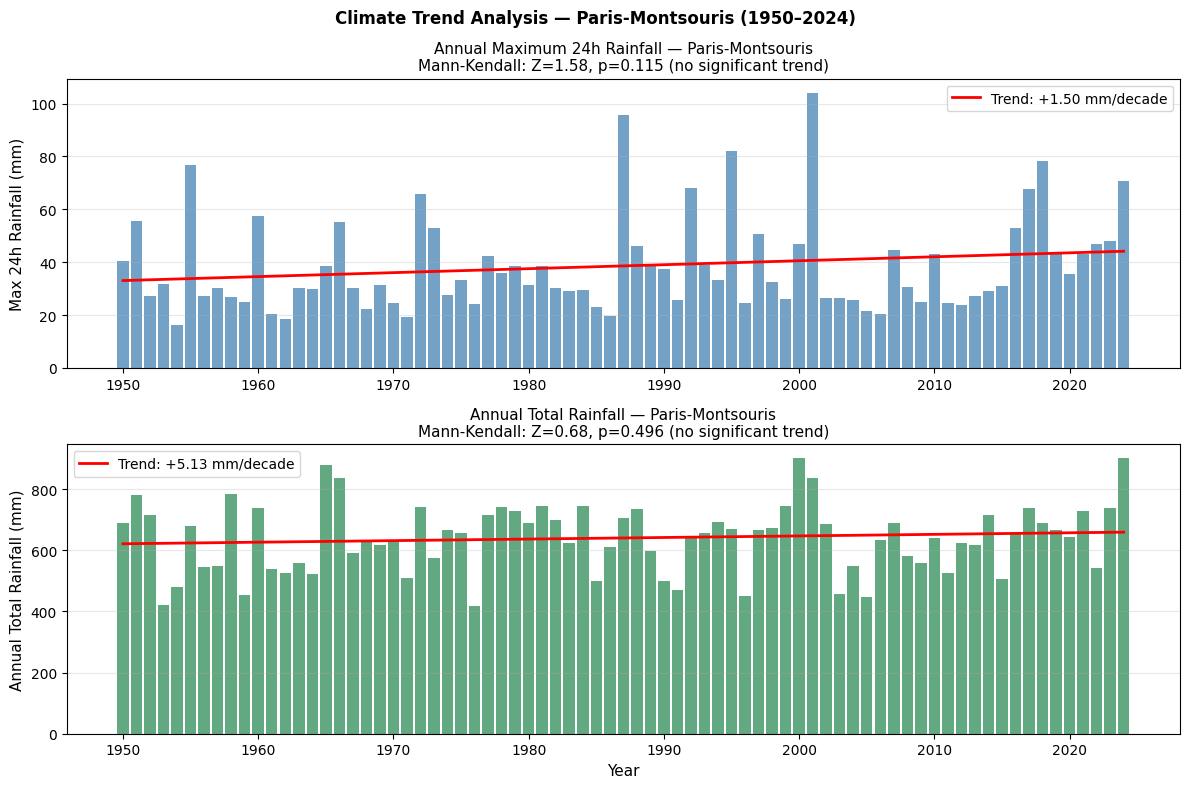

Saved: results/trend_analysis.png


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
 
# Panel 1 — 24h maxima
ax1.bar(am_daily.index, am_daily['annual_max_24h_mm'],
        color='steelblue', alpha=0.75, width=0.85)
ax1.plot(yrs_max, ic1 + sl1 * yrs_max, 'r-', lw=2,
         label=f'Trend: {sl1*10:+.2f} mm/decade')
ax1.set_ylabel('Max 24h Rainfall (mm)', fontsize=11)
ax1.set_title(f'Annual Maximum 24h Rainfall — Paris-Montsouris\n'
              f'Mann-Kendall: Z={Z1:.2f}, p={p1:.3f} ({t1})',
              fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
 
# Panel 2 — annual totals
ax2.bar(annual_total.index, annual_total.values,
        color='seagreen', alpha=0.75, width=0.85)
ax2.plot(yrs_tot, ic2 + sl2 * yrs_tot, 'r-', lw=2,
         label=f'Trend: {sl2*10:+.2f} mm/decade')
ax2.set_ylabel('Annual Total Rainfall (mm)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title(f'Annual Total Rainfall — Paris-Montsouris\n'
              f'Mann-Kendall: Z={Z2:.2f}, p={p2:.3f} ({t2})',
              fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
 
plt.suptitle('Climate Trend Analysis — Paris-Montsouris (1950–2024)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/trend_analysis.png")
 

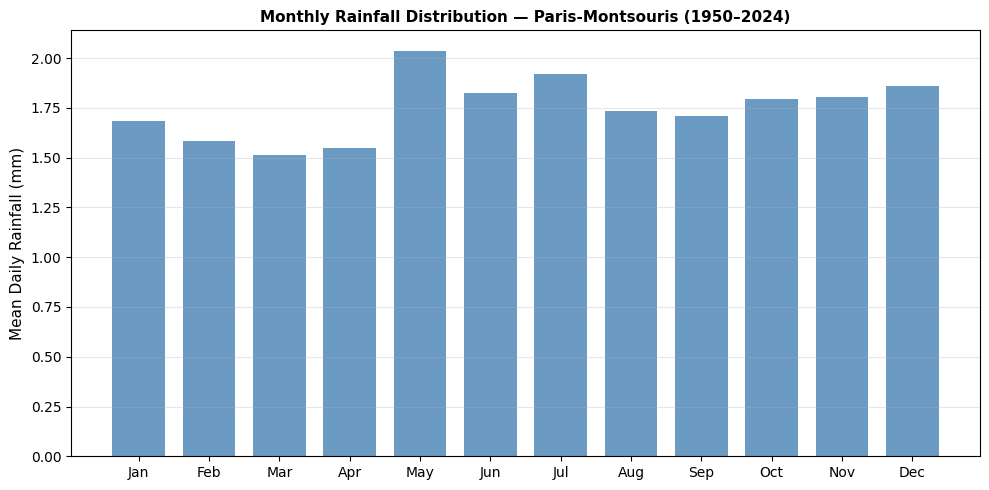

Saved: results/monthly_distribution.png


In [5]:
monthly_mean = df.groupby('month')['RR'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), monthly_mean.values,
       color='steelblue', alpha=0.8, width=0.75)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Mean Daily Rainfall (mm)', fontsize=11)
ax.set_title('Monthly Rainfall Distribution — Paris-Montsouris (1950–2024)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/monthly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/monthly_distribution.png")

In [6]:
split = 1986
p1_data = am_daily[am_daily.index <  split]['annual_max_24h_mm'].dropna().values
p2_data = am_daily[am_daily.index >= split]['annual_max_24h_mm'].dropna().values
 
sh1, lo1, sc1 = genextreme.fit(p1_data)
sh2, lo2, sc2 = genextreme.fit(p2_data)
 
RPs = [2, 5, 10, 20, 50, 100]
rows = {}
for T in RPs:
    d1 = genextreme.ppf(1 - 1/T, sh1, loc=lo1, scale=sc1)
    d2 = genextreme.ppf(1 - 1/T, sh2, loc=lo2, scale=sc2)
    rows[T] = {'1950-1985 (mm)': d1, '1986-2024 (mm)': d2,
               'Change (mm)': d2 - d1, 'Change (%)': (d2 - d1)/d1*100}
 
cmp = pd.DataFrame(rows).T
cmp.index.name = 'Return Period (yr)'
print(f"Split-period comparison (pre/post {split}):")
print(cmp.round(1))
cmp.round(2).to_csv('../results/split_period_comparison.csv')
print("\nSaved: results/split_period_comparison.csv")
print("\nNB05 COMPLETE")

Split-period comparison (pre/post 1986):
                    1950-1985 (mm)  1986-2024 (mm)  Change (mm)  Change (%)
Return Period (yr)                                                         
2                             31.0            35.2          4.2        13.5
5                             42.4            53.4         11.0        25.9
10                            51.3            71.2         19.9        38.9
20                            60.9            94.5         33.6        55.2
50                            75.2           137.2         62.0        82.4
100                           87.5           182.1         94.6       108.2

Saved: results/split_period_comparison.csv

NB05 COMPLETE
